In [1]:
!pip install -q timm
!pip install -q scikit-image
!pip install -q seaborn

In [2]:
!pip install -q transformers

In [3]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [4]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/dataset
dataset/dataset/noise
dataset/dataset/compression
dataset/dataset/crop
dataset/dataset/original
dataset/dataset/screenshot
dataset/dataset/text_overlay
dataset/__MACOSX
dataset/__MACOSX/dataset
dataset/__MACOSX/dataset/original


In [6]:
import os
import cv2
import torch
import timm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from skimage.metrics import structural_similarity as ssim

from transformers import (
    CLIPProcessor,
    CLIPModel
)

import torchvision.transforms as transforms

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cpu


In [8]:
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("CLIP Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP Loaded


In [9]:
dino_model = torch.hub.load(
    'facebookresearch/dinov2',
    'dinov2_vitb14'
)

dino_model.eval()

dino_model = dino_model.to(device)

print("DINO Loaded")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:03<00:00, 105MB/s]


DINO Loaded


In [10]:
dino_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [23]:
def get_clip_embedding(path):

    image = Image.open(path).convert("RGB")

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k:v.to(device)
        for k,v in inputs.items()
    }

    with torch.no_grad():

        outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        features = outputs.pooler_output

    features = features.cpu().numpy()[0]

    features = features / (
        np.linalg.norm(features) + 1e-10
    )

    return features

In [12]:
def get_dino_embedding(path):

    image = Image.open(path).convert("RGB")

    image = dino_transform(image)

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():

        features = dino_model(image)

    features = features.cpu().numpy()[0]

    features = features / (
        np.linalg.norm(features)+1e-10
    )

    return features

In [13]:
original_folder = Path("dataset/original")

transformations = [
    "crop",
    "compression",
    "screenshot",
    "text_overlay",
    "noise"
]

In [15]:
import shutil
import os

if os.path.exists("dataset/dataset"):
    shutil.move("dataset/dataset/original","dataset/original")
    shutil.move("dataset/dataset/crop","dataset/crop")
    shutil.move("dataset/dataset/compression","dataset/compression")
    shutil.move("dataset/dataset/screenshot","dataset/screenshot")
    shutil.move("dataset/dataset/text_overlay","dataset/text_overlay")
    shutil.move("dataset/dataset/noise","dataset/noise")

print("Folders moved successfully.")

Folders moved successfully.


In [24]:
clip_results = []

for img_file in original_folder.iterdir():

    if not img_file.is_file():
        continue

    try:

        original_embedding = get_clip_embedding(
            str(img_file)
        )

        for trans in transformations:

            transformed_path = (
                Path("dataset")
                / trans
                / img_file.name
            )

            if not transformed_path.exists():
                continue

            transformed_embedding = get_clip_embedding(
                str(transformed_path)
            )

            similarity = np.dot(
                original_embedding,
                transformed_embedding
            )

            clip_results.append([
                img_file.name,
                trans,
                similarity
            ])

    except Exception as e:

        print(img_file.name, e)

df_clip = pd.DataFrame(
    clip_results,
    columns=[
        "Image",
        "Transformation",
        "CLIP"
    ]
)

df_clip.head()

,Image,Transformation,CLIP
0,000000011122.jpg,crop,0.881045
1,000000011122.jpg,compression,0.923844
2,000000011122.jpg,screenshot,0.892391
3,000000011122.jpg,text_overlay,0.618612
4,000000011122.jpg,noise,0.782478


In [17]:
dino_results = []

for img_file in original_folder.iterdir():

    if not img_file.is_file():
        continue

    try:

        original_embedding = get_dino_embedding(
            str(img_file)
        )

        for trans in transformations:

            transformed_path = (
                Path("dataset")
                / trans
                / img_file.name
            )

            if not transformed_path.exists():
                continue

            transformed_embedding = get_dino_embedding(
                str(transformed_path)
            )

            similarity = np.dot(
                original_embedding,
                transformed_embedding
            )

            dino_results.append([
                img_file.name,
                trans,
                similarity
            ])

    except Exception as e:

        print(img_file.name, e)

df_dino = pd.DataFrame(
    dino_results,
    columns=[
        "Image",
        "Transformation",
        "DINO"
    ]
)

df_dino.head()

,Image,Transformation,DINO
0,000000011122.jpg,crop,0.900418
1,000000011122.jpg,compression,0.981348
2,000000011122.jpg,screenshot,0.962716
3,000000011122.jpg,text_overlay,0.992945
4,000000011122.jpg,noise,0.958883


In [18]:
ssim_results = []

for img_file in original_folder.iterdir():

    try:

        original = cv2.imread(
            str(img_file),
            cv2.IMREAD_GRAYSCALE
        )

        for trans in transformations:

            transformed_path = (
                Path("dataset")
                / trans
                / img_file.name
            )

            if not transformed_path.exists():
                continue

            transformed = cv2.imread(
                str(transformed_path),
                cv2.IMREAD_GRAYSCALE
            )

            transformed = cv2.resize(
                transformed,
                (
                    original.shape[1],
                    original.shape[0]
                )
            )

            score = ssim(
                original,
                transformed
            )

            ssim_results.append([
                img_file.name,
                trans,
                score
            ])

    except Exception as e:

        print(img_file.name,e)

df_ssim = pd.DataFrame(
    ssim_results,
    columns=[
        "Image",
        "Transformation",
        "SSIM"
    ]
)

df_ssim.head()

,Image,Transformation,SSIM
0,000000011122.jpg,crop,0.096371
1,000000011122.jpg,compression,0.848456
2,000000011122.jpg,screenshot,0.056453
3,000000011122.jpg,text_overlay,0.955231
4,000000011122.jpg,noise,0.752549


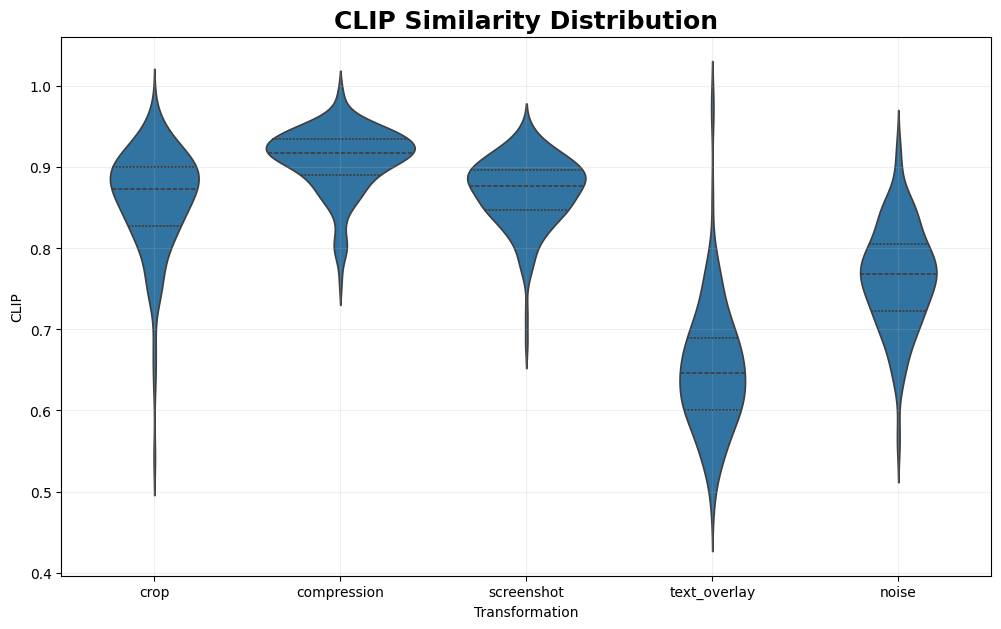

In [25]:
plt.figure(figsize=(12,7))

sns.violinplot(
    data=df_clip,
    x="Transformation",
    y="CLIP",
    inner="quartile"
)

plt.title(
    "CLIP Similarity Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.savefig(
    "CLIP_Violin.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

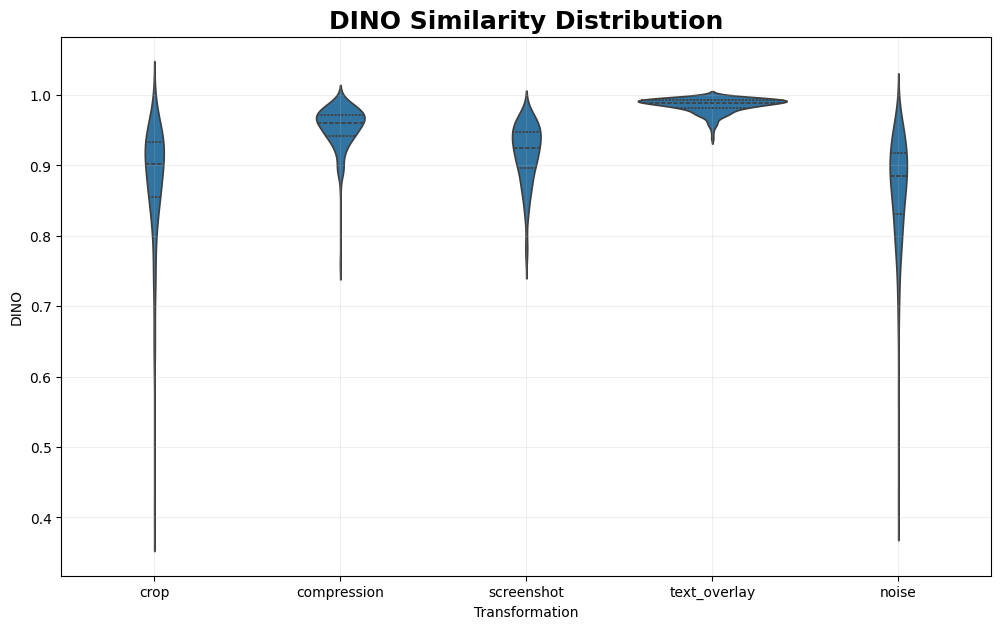

In [26]:
plt.figure(figsize=(12,7))

sns.violinplot(
    data=df_dino,
    x="Transformation",
    y="DINO",
    inner="quartile"
)

plt.title(
    "DINO Similarity Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.savefig(
    "DINO_Violin.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

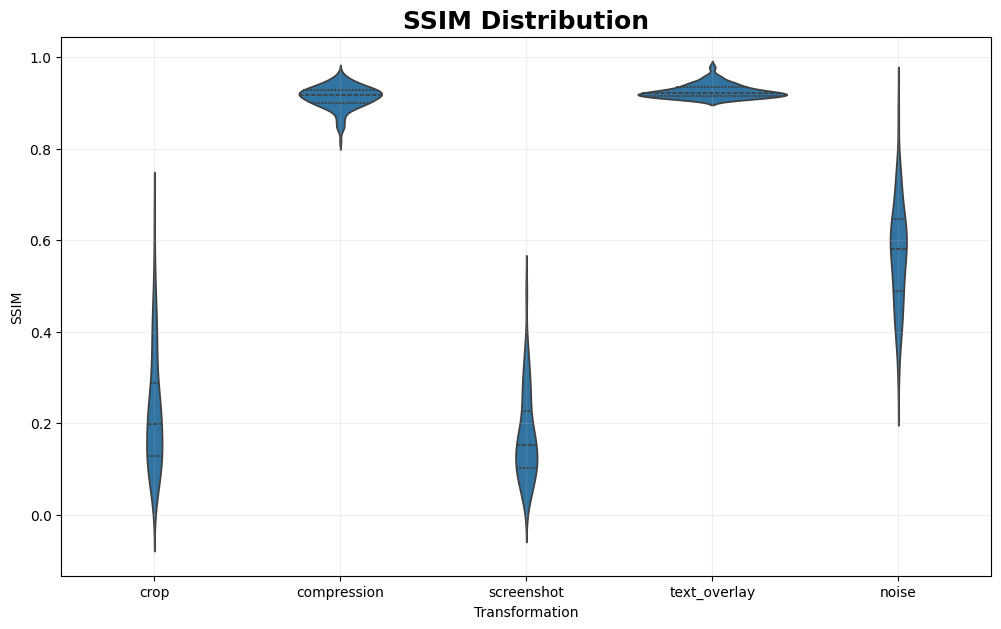

In [21]:
plt.figure(figsize=(12,7))

sns.violinplot(
    data=df_ssim,
    x="Transformation",
    y="SSIM",
    inner="quartile"
)

plt.title(
    "SSIM Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.savefig(
    "SSIM_Violin.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [27]:
df_clip.to_csv(
    "clip_results.csv",
    index=False
)

df_dino.to_csv(
    "dino_results.csv",
    index=False
)

df_ssim.to_csv(
    "ssim_results.csv",
    index=False
)

print("All CSV files saved.")

All CSV files saved.


/tmp/ipykernel_9647/1569907488.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


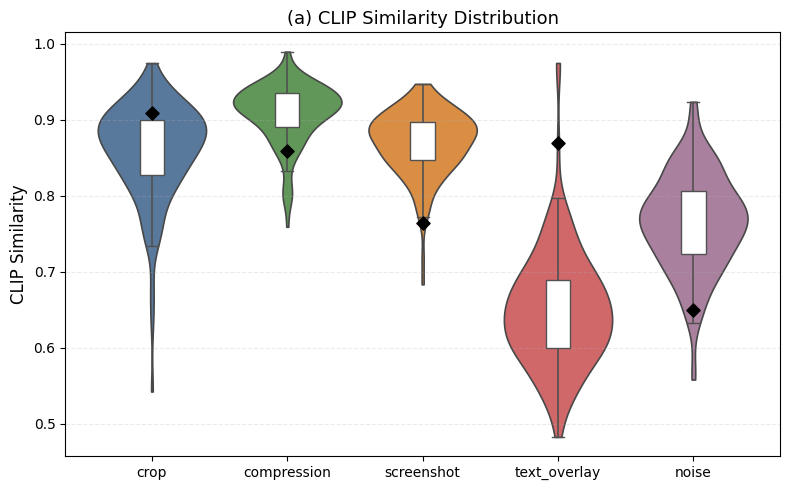

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

palette = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#E15759",
    "#B07AA1"
]

ax = sns.violinplot(
    data=df_clip,
    x="Transformation",
    y="CLIP",
    palette=palette,
    inner=None,
    cut=0,
    linewidth=1.2
)

sns.boxplot(
    data=df_clip,
    x="Transformation",
    y="CLIP",
    width=0.18,
    showcaps=True,
    boxprops={'facecolor':'white','zorder':3},
    whiskerprops={'linewidth':1.2},
    medianprops={'color':'black','linewidth':2},
    showfliers=False
)

means = df_clip.groupby("Transformation")["CLIP"].mean()

for i, mean in enumerate(means):
    plt.scatter(
        i,
        mean,
        color="black",
        marker="D",
        s=45,
        zorder=5
    )

plt.ylabel("CLIP Similarity", fontsize=12)
plt.xlabel("")
plt.title("(a) CLIP Similarity Distribution", fontsize=13)

plt.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()

plt.savefig(
    "CLIP_Publication.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

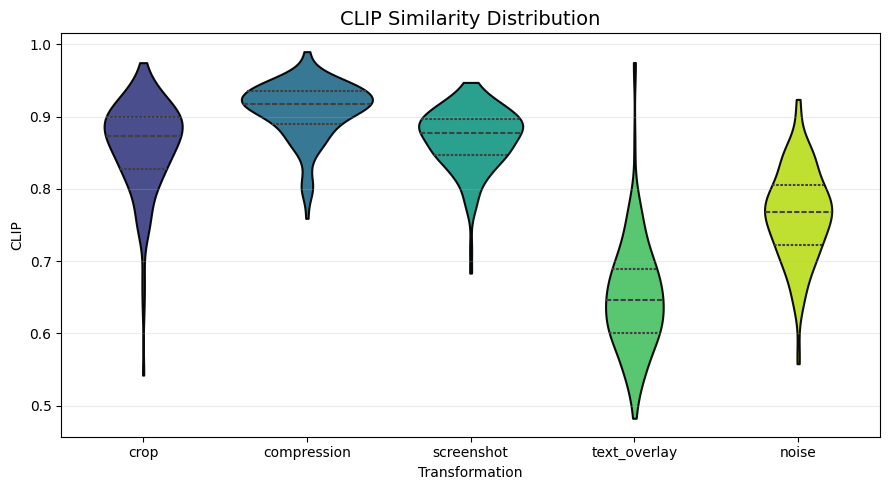

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(9,5))

vp = sns.violinplot(
    data=df_clip,
    x="Transformation",
    y="CLIP",
    inner="quartile",
    cut=0,
    linewidth=1.5
)

# Apply gradient-like colors
colors = cm.viridis(np.linspace(0.2, 0.9, len(ax.collections)))

for violin, color in zip(ax.collections[:5], colors):
    violin.set_facecolor(color)
    violin.set_edgecolor("black")
    violin.set_alpha(0.95)

plt.title("CLIP Similarity Distribution", fontsize=14)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [30]:
!pip install ptitprince

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 37.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16217 sha256=a2c3ff626990eed7e40f4ef64b07c52dff273e33e93a0863b78fe8e87b273f1e
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


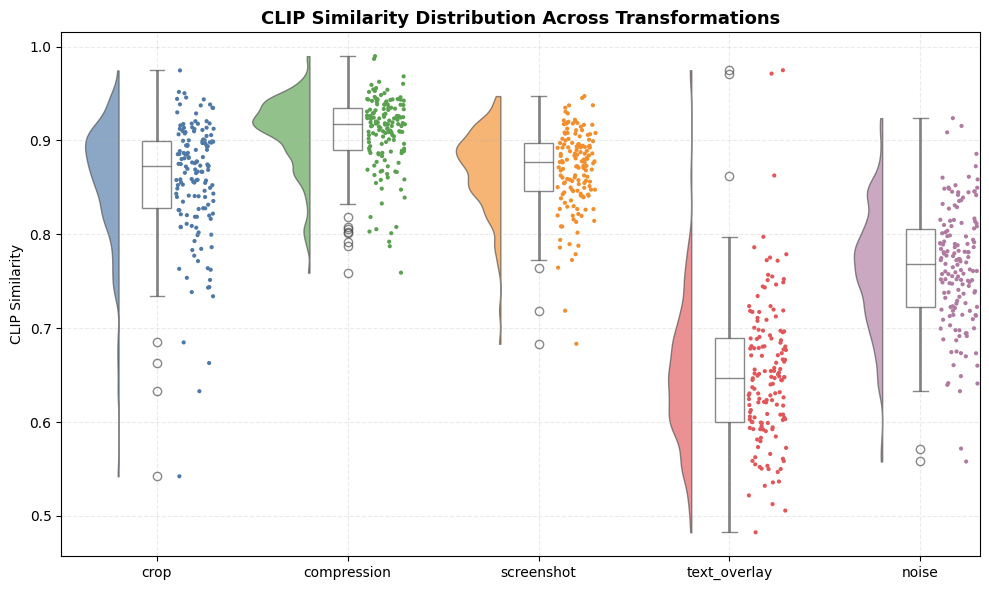

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt

plt.rcParams["font.family"] = "Times New Roman"

palette = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#E15759",
    "#B07AA1"
]

fig, ax = plt.subplots(figsize=(10,6))

pt.RainCloud(
    x="Transformation",
    y="CLIP",
    data=df_clip,
    palette=palette,
    bw=.2,
    width_viol=.6,
    orient="v",
    move=.2,
    alpha=.65,
    ax=ax
)

plt.title(
    "CLIP Similarity Distribution Across Transformations",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("CLIP Similarity")
plt.xlabel("")
plt.grid(alpha=0.25, linestyle="--")

plt.tight_layout()

plt.savefig(
    "CLIP_Raincloud.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


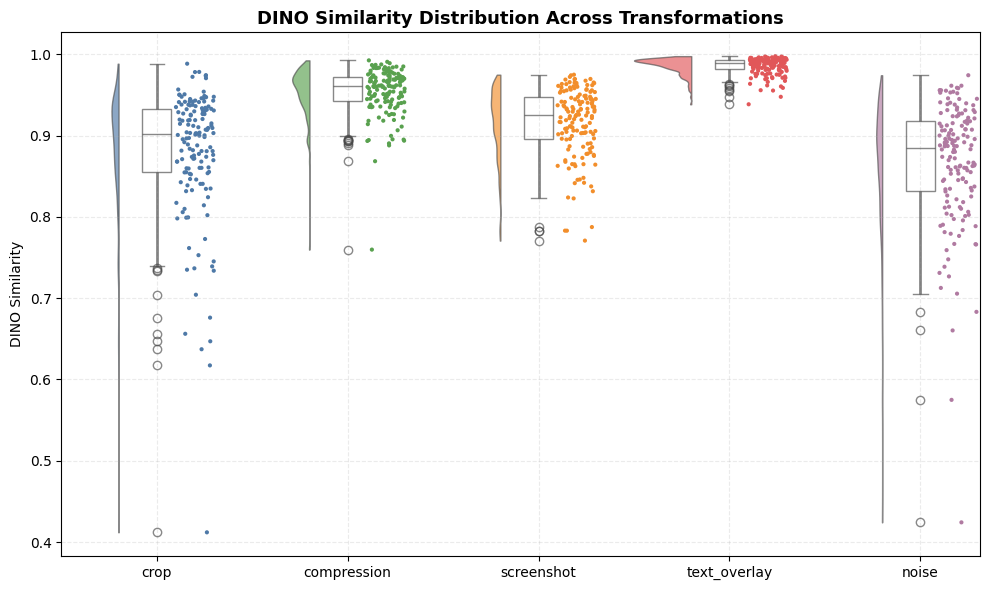

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt

plt.rcParams["font.family"] = "Times New Roman"

palette = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#E15759",
    "#B07AA1"
]

fig, ax = plt.subplots(figsize=(10,6))

pt.RainCloud(
    x="Transformation",
    y="DINO",
    data=df_dino,
    palette=palette,
    bw=.2,
    width_viol=.6,
    orient="v",
    move=.2,
    alpha=.65,
    ax=ax
)

plt.title(
    "DINO Similarity Distribution Across Transformations",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("DINO Similarity")
plt.xlabel("")
plt.grid(alpha=0.25, linestyle="--")

plt.tight_layout()

plt.savefig(
    "DINO_Raincloud.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


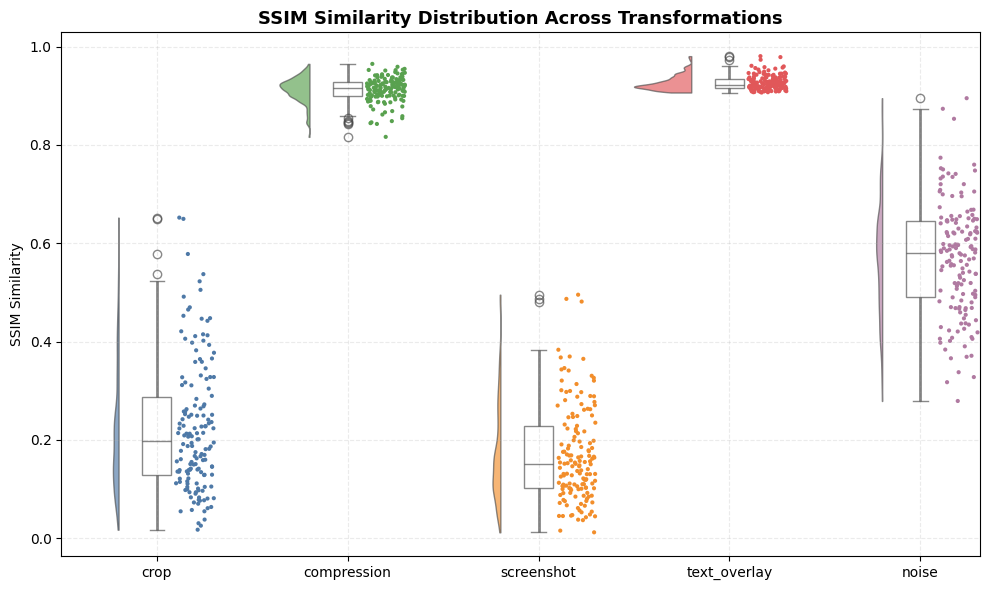

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt

plt.rcParams["font.family"] = "Times New Roman"

palette = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#E15759",
    "#B07AA1"
]

fig, ax = plt.subplots(figsize=(10,6))

pt.RainCloud(
    x="Transformation",
    y="SSIM",
    data=df_ssim,
    palette=palette,
    bw=.2,
    width_viol=.6,
    orient="v",
    move=.2,
    alpha=.65,
    ax=ax
)

plt.title(
    "SSIM Similarity Distribution Across Transformations",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("SSIM Similarity")
plt.xlabel("")
plt.grid(alpha=0.25, linestyle="--")

plt.tight_layout()

plt.savefig(
    "SSIM_Raincloud.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()